In [1]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Khai bao duong dan


In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MERGED_CSV = PROJECT_ROOT / "data" / "processed" / "student_voice_merged.csv"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EDA_REPORT = REPORT_DIR / "eda_report.md"

print("Project root:", PROJECT_ROOT)
print("Merged CSV:", MERGED_CSV)
print("Figure dir:", FIGURE_DIR)
print("EDA report:", EDA_REPORT)

Project root: d:\AI thuc chien\Student Voice Intelligence
Merged CSV: d:\AI thuc chien\Student Voice Intelligence\data\processed\student_voice_merged.csv
Figure dir: d:\AI thuc chien\Student Voice Intelligence\outputs\figures
EDA report: d:\AI thuc chien\Student Voice Intelligence\outputs\reports\eda_report.md


## 2. Load du lieu merged


In [ ]:

df = pd.read_csv(MERGED_CSV)

print("Shape:", df.shape)
display(df.head())

Shape: (49141, 11)


,text,source_dataset,split_original,sentiment_raw,sentiment_std_code,sentiment_std_3class,sentiment_std_4class,topic_raw,topic_std,is_toxic,urgency_level
0,em xin chào các anh chị em em là sinh viên vừa...,NEU_ESC,train,0,0,neutral,neutral,2,academic,0,low
1,xây dựng mô hình sư phạm chuẩn mực sáng tạo ti...,NEU_ESC,train,0,0,neutral,neutral,2,academic,0,low
2,sao lại ghét cái kiểu làm sai xong khóc lóc ăn...,NEU_ESC,train,2,2,negative,negative,3,others,0,low
3,chào thầy đăng ký học ghép . môn học hiện hệ t...,NEU_ESC,train,0,0,neutral,neutral,2,academic,0,low
4,con bé vẫn hoang mang lắm .,NEU_ESC,train,2,2,negative,negative,3,others,0,low


## 3. Kiem tra schema


In [4]:
REQUIRED_COLUMNS = [
    "text",
    "source_dataset",
    "split_original",
    "sentiment_raw",
    "sentiment_std_3class",
    "sentiment_std_4class",
    "topic_raw",
    "topic_std",
]

OPTIONAL_COLUMNS = ["sentiment_std_code", "is_toxic", "urgency_level"]

missing_required = [col for col in REQUIRED_COLUMNS if col not in df.columns]
missing_optional = [col for col in OPTIONAL_COLUMNS if col not in df.columns]

if missing_required:
    raise ValueError(f"File merged thieu cot bat buoc: {missing_required}")

if missing_optional:
    print("Cot optional dang thieu:", missing_optional)
    print("Neu muon dung schema moi nhat, hay rerun notebook 01_data_merge.ipynb.")

print("Columns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

Columns:
['text', 'source_dataset', 'split_original', 'sentiment_raw', 'sentiment_std_code', 'sentiment_std_3class', 'sentiment_std_4class', 'topic_raw', 'topic_std', 'is_toxic', 'urgency_level']

Dtypes:
text                    object
source_dataset          object
split_original          object
sentiment_raw            int64
sentiment_std_code       int64
sentiment_std_3class    object
sentiment_std_4class    object
topic_raw                int64
topic_std               object
is_toxic                 int64
urgency_level           object
dtype: object


## 4. Tong quan missing, duplicate, split


In [5]:
total_rows = len(df)
total_columns = len(df.columns)
missing_table = df.isna().sum().sort_values(ascending=False).rename("missing_count").to_frame()
missing_table["missing_pct"] = (missing_table["missing_count"] / total_rows * 100).round(3)

duplicate_text_count = int(df.duplicated(subset=["text"]).sum())

duplicate_groups = df[df.duplicated(subset=["text"], keep=False)].copy()
duplicate_cross_split = (
    duplicate_groups.groupby("text")["split_original"].nunique().gt(1).sum()
    if len(duplicate_groups) > 0
    else 0
)

print("Rows:", total_rows)
print("Columns:", total_columns)
print("Duplicate text rows:", duplicate_text_count)
print("Duplicate text groups across splits:", int(duplicate_cross_split))

display(missing_table)

Rows: 49141
Columns: 11
Duplicate text rows: 1
Duplicate text groups across splits: 0


,missing_count,missing_pct
text,0,0.0
source_dataset,0,0.0
split_original,0,0.0
sentiment_raw,0,0.0
sentiment_std_code,0,0.0
sentiment_std_3class,0,0.0
sentiment_std_4class,0,0.0
topic_raw,0,0.0
topic_std,0,0.0
is_toxic,0,0.0


## 5. Ham ve bieu do


In [6]:
def save_bar_plot(series, title, xlabel, ylabel, filename, horizontal=False, sort_values=True):
    counts = series.value_counts(dropna=False)
    if sort_values:
        counts = counts.sort_values(ascending=True if horizontal else False)

    plt.figure(figsize=(10, max(4, 0.4 * len(counts))) if horizontal else (8, 5))
    if horizontal:
        plt.barh(counts.index.astype(str), counts.values)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
    else:
        plt.bar(counts.index.astype(str), counts.values)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xticks(rotation=30, ha="right")

    plt.title(title)
    plt.tight_layout()
    output_path = FIGURE_DIR / filename
    plt.savefig(output_path, dpi=160)
    plt.show()
    return output_path


def distribution_table(series):
    counts = series.value_counts(dropna=False)
    table = counts.rename("count").to_frame()
    table["pct"] = (table["count"] / table["count"].sum() * 100).round(2)
    return table


figure_paths = []

## 6. Phan bo source va split


,count,pct
source_dataset,,
NEU_ESC,32966,67.08
UIT_VSFC,16175,32.92


,count,pct
split_original,,
train,34474,70.15
test,9779,19.90
validation,4888,9.95


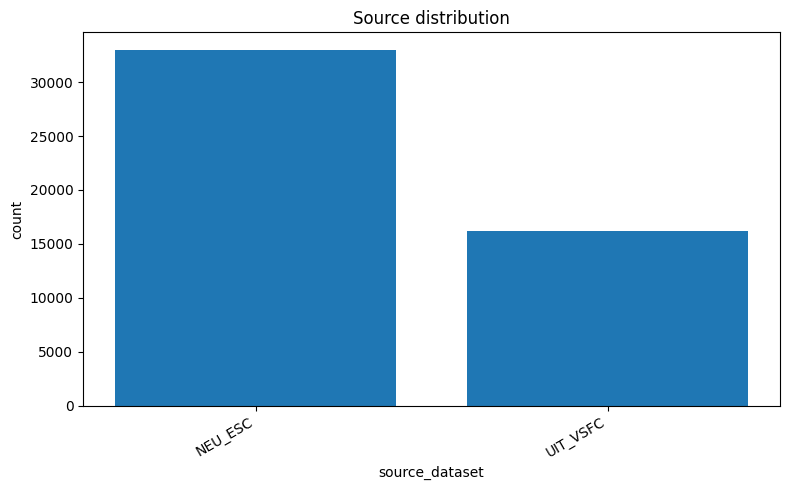

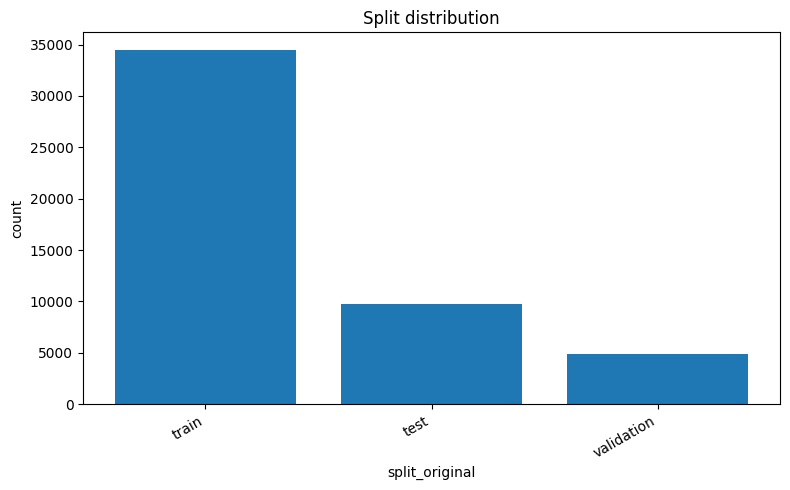

In [7]:
display(distribution_table(df["source_dataset"]))
display(distribution_table(df["split_original"]))

figure_paths.append(save_bar_plot(df["source_dataset"], "Source distribution", "source_dataset", "count", "source_distribution.png"))
figure_paths.append(save_bar_plot(df["split_original"], "Split distribution", "split_original", "count", "split_distribution.png"))

## 7. Phan bo sentiment



 sentiment_std_code


,count,pct
sentiment_std_code,,
0,23471,47.76
2,12639,25.72
1,12186,24.80
3,845,1.72


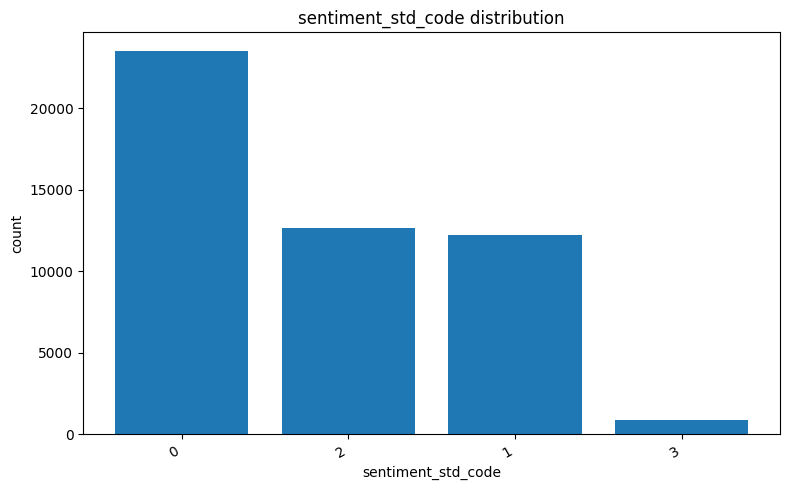


 sentiment_std_3class


,count,pct
sentiment_std_3class,,
neutral,23471,47.76
negative,13484,27.44
positive,12186,24.80


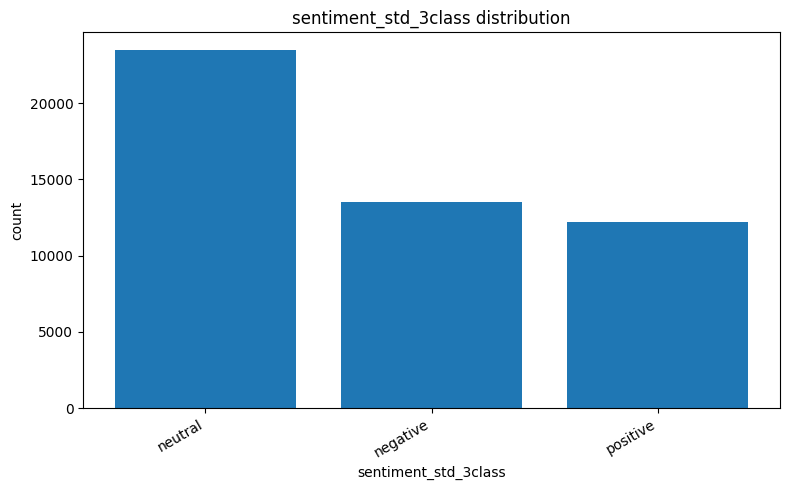


 sentiment_std_4class


,count,pct
sentiment_std_4class,,
neutral,23471,47.76
negative,12639,25.72
positive,12186,24.80
toxic,845,1.72


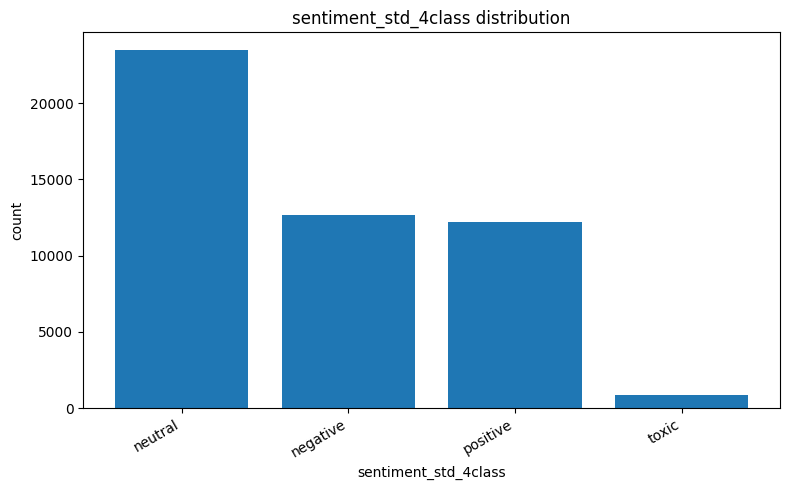

In [8]:
sentiment_columns = []
if "sentiment_std_code" in df.columns:
    sentiment_columns.append("sentiment_std_code")
sentiment_columns.extend(["sentiment_std_3class", "sentiment_std_4class"])

for col in sentiment_columns:
    print("\n", col)
    display(distribution_table(df[col]))
    figure_paths.append(
        save_bar_plot(
            df[col],
            f"{col} distribution",
            col,
            "count",
            f"{col}_distribution.png",
        )
    )

## 8. Phan bo topic


,count,pct
topic_std,,
others,15218,30.97
lecturer,11607,23.62
academic,10512,21.39
training_program,3040,6.19
student_services,2358,4.80
personal_affairs,1478,3.01
news,902,1.84
jobs_recruitment,808,1.64
social_affairs,769,1.56


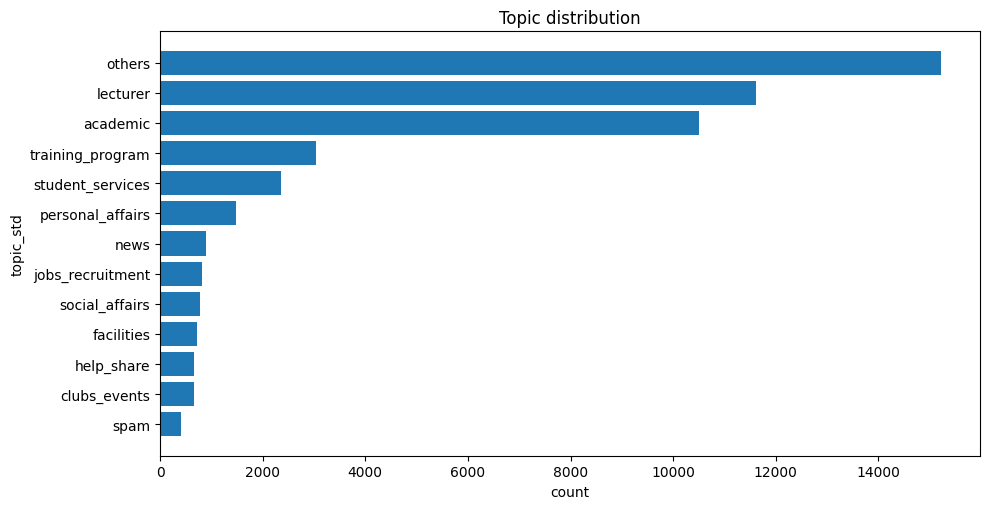

source_dataset,NEU_ESC,UIT_VSFC
topic_std,,
academic,10512,0
clubs_events,662,0
facilities,0,712
help_share,670,0
jobs_recruitment,808,0
lecturer,0,11607
news,902,0
others,14402,816
personal_affairs,1478,0


source_dataset,NEU_ESC,UIT_VSFC
topic_std,,
academic,31.89,0.00
clubs_events,2.01,0.00
facilities,0.00,4.40
help_share,2.03,0.00
jobs_recruitment,2.45,0.00
lecturer,0.00,71.76
news,2.74,0.00
others,43.69,5.04
personal_affairs,4.48,0.00


In [9]:
display(distribution_table(df["topic_std"]))
figure_paths.append(save_bar_plot(df["topic_std"], "Topic distribution", "count", "topic_std", "topic_distribution.png", horizontal=True))

topic_by_source = pd.crosstab(df["topic_std"], df["source_dataset"])
display(topic_by_source)

topic_by_source_pct = (topic_by_source.div(topic_by_source.sum(axis=0), axis=1) * 100).round(2)
display(topic_by_source_pct)

## 9. Toxic va urgency neu co


,count,pct
is_toxic,,
0,48296,98.28
1,845,1.72


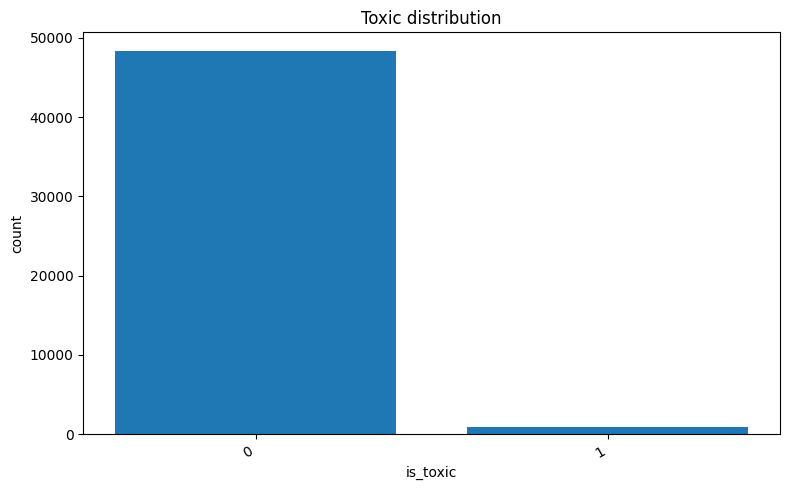

,count,pct
urgency_level,,
low,49141,100.0


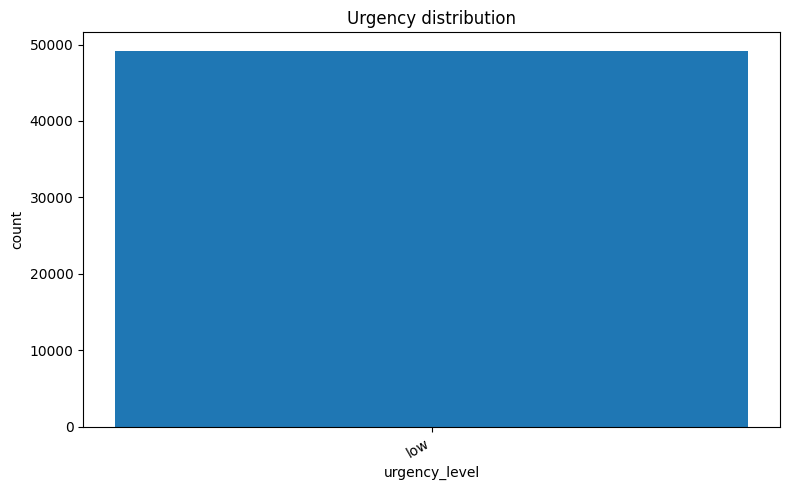

In [10]:
if "is_toxic" in df.columns:
    display(distribution_table(df["is_toxic"]))
    figure_paths.append(save_bar_plot(df["is_toxic"], "Toxic distribution", "is_toxic", "count", "toxic_distribution.png"))

if "urgency_level" in df.columns:
    display(distribution_table(df["urgency_level"]))
    figure_paths.append(save_bar_plot(df["urgency_level"], "Urgency distribution", "urgency_level", "count", "urgency_distribution.png"))

## 10. Do dai text


,char_count,word_count
count,49141.00,49141.00
mean,89.57,21.51
std,180.29,41.19
min,3.00,1.00
25%,31.00,8.00
50%,48.00,12.00
75%,85.00,20.00
90%,166.00,40.00
95%,269.00,63.00
99%,747.00,171.00


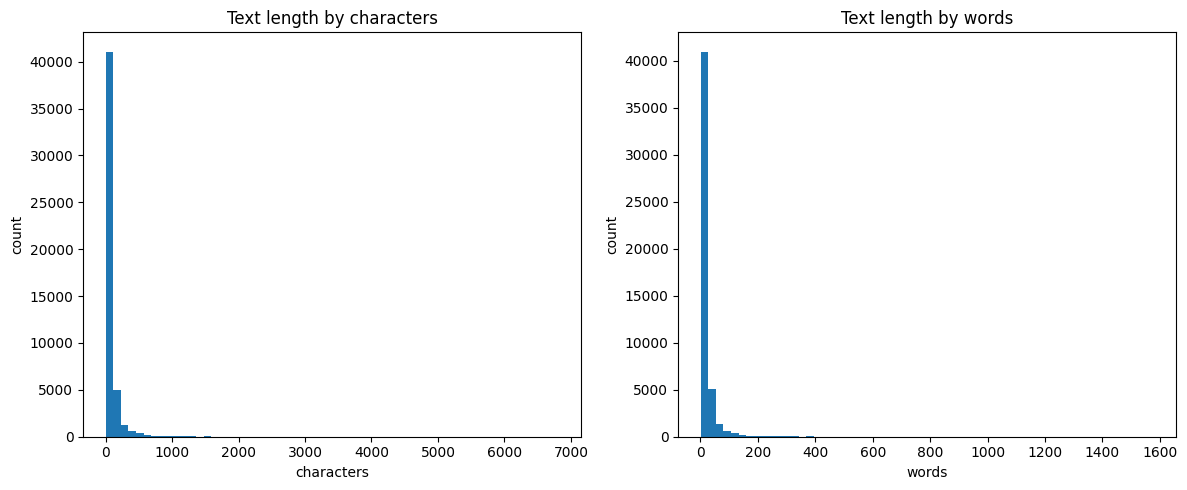

In [11]:
eda_df = df.copy()
eda_df["text"] = eda_df["text"].fillna("").astype(str)
eda_df["char_count"] = eda_df["text"].str.len()
eda_df["word_count"] = eda_df["text"].str.split().map(len)

length_summary = eda_df[["char_count", "word_count"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)
display(length_summary)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(eda_df["char_count"], bins=60)
plt.title("Text length by characters")
plt.xlabel("characters")
plt.ylabel("count")

plt.subplot(1, 2, 2)
plt.hist(eda_df["word_count"], bins=60)
plt.title("Text length by words")
plt.xlabel("words")
plt.ylabel("count")

plt.tight_layout()
text_length_path = FIGURE_DIR / "text_length_distribution.png"
plt.savefig(text_length_path, dpi=160)
plt.show()
figure_paths.append(text_length_path)

## 11. Mau text ngan/dai bat thuong


In [12]:
print("Shortest texts:")
display(eda_df.sort_values("word_count").head(10)[["text", "source_dataset", "split_original", "sentiment_std_3class", "topic_std", "word_count"]])

print("Longest texts:")
display(eda_df.sort_values("word_count", ascending=False).head(10)[["text", "source_dataset", "split_original", "sentiment_std_3class", "topic_std", "word_count"]])

Shortest texts:


,text,source_dataset,split_original,sentiment_std_3class,topic_std,word_count
9703,dcu,NEU_ESC,train,negative,others,1
27396,dốt,NEU_ESC,test,negative,others,1
46016,ổn .,UIT_VSFC,test,neutral,others,2
42243,giỏi .,UIT_VSFC,train,positive,others,2
17953,trường lồn,NEU_ESC,train,negative,academic,2
25751,lớp lồn,NEU_ESC,validation,negative,academic,2
48083,tạm .,UIT_VSFC,test,neutral,others,2
48053,tuyệt .,UIT_VSFC,test,positive,others,2
40089,thân !,UIT_VSFC,train,neutral,others,2
33722,nope .,UIT_VSFC,train,neutral,others,2


Longest texts:


,text,source_dataset,split_original,sentiment_std_3class,topic_std,word_count
21343,tân cử nhân u70 tuổi nhận bằng tốt nghiệp ngàn...,NEU_ESC,train,neutral,news,1578
7428,các em sinh viên thân mến theo thông tin sơ bộ...,NEU_ESC,train,negative,help_share,1570
28699,chia sẻ kinh nghiệm viết và xuất bản sách . tr...,NEU_ESC,test,neutral,academic,1468
10623,chính thức thông báo lịch thi tiếng anh đầu và...,NEU_ESC,train,neutral,news,1218
13072,em mình xin chào các bạn trong group em xin ph...,NEU_ESC,train,negative,personal_affairs,1195
9771,sinh viên ngoại thương đọc sách ngầu tư kinh t...,NEU_ESC,train,neutral,academic,1171
8454,trải nghiệm trap boi đời đầu tân sinh viên trư...,NEU_ESC,train,negative,academic,1057
30605,góc chia sẻ nhân dịp có khóa mới và nhiều bài ...,NEU_ESC,test,negative,student_services,1035
22590,chúng ta có quyền lựa chọn mà mình hiện đang l...,NEU_ESC,train,neutral,clubs_events,1007
1037,là sinh viên năm nhất thì nên quan tâm tới nhữ...,NEU_ESC,train,neutral,help_share,953


## 12. Heatmap sentiment theo topic


sentiment_std_3class,negative,neutral,positive
topic_std,,,
academic,1507,7827,1178
clubs_events,13,450,199
facilities,681,13,18
help_share,39,574,57
jobs_recruitment,100,619,89
lecturer,4105,292,7210
news,46,811,45
others,3037,10229,1952
personal_affairs,569,458,451


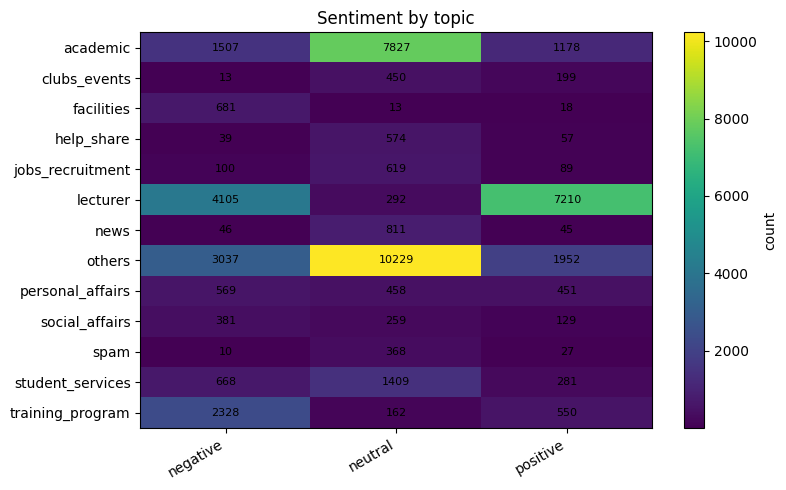

In [13]:
sentiment_topic = pd.crosstab(df["topic_std"], df["sentiment_std_3class"])
display(sentiment_topic)

plt.figure(figsize=(8, max(5, 0.35 * len(sentiment_topic))))
plt.imshow(sentiment_topic.values, aspect="auto")
plt.colorbar(label="count")
plt.xticks(range(len(sentiment_topic.columns)), sentiment_topic.columns, rotation=30, ha="right")
plt.yticks(range(len(sentiment_topic.index)), sentiment_topic.index)
plt.title("Sentiment by topic")

for row_idx in range(sentiment_topic.shape[0]):
    for col_idx in range(sentiment_topic.shape[1]):
        value = sentiment_topic.iloc[row_idx, col_idx]
        plt.text(col_idx, row_idx, str(value), ha="center", va="center", fontsize=8)

plt.tight_layout()
heatmap_path = FIGURE_DIR / "sentiment_topic_heatmap.png"
plt.savefig(heatmap_path, dpi=160)
plt.show()
figure_paths.append(heatmap_path)

## 13. Top tu trong feedback negative


,word,count
0,học,4992
1,bài,2282
2,giảng,2122
3,nhiều,2067
4,đi,2045
5,làm,1778
6,người,1745
7,hơn,1605
8,thực,1583
9,trường,1560


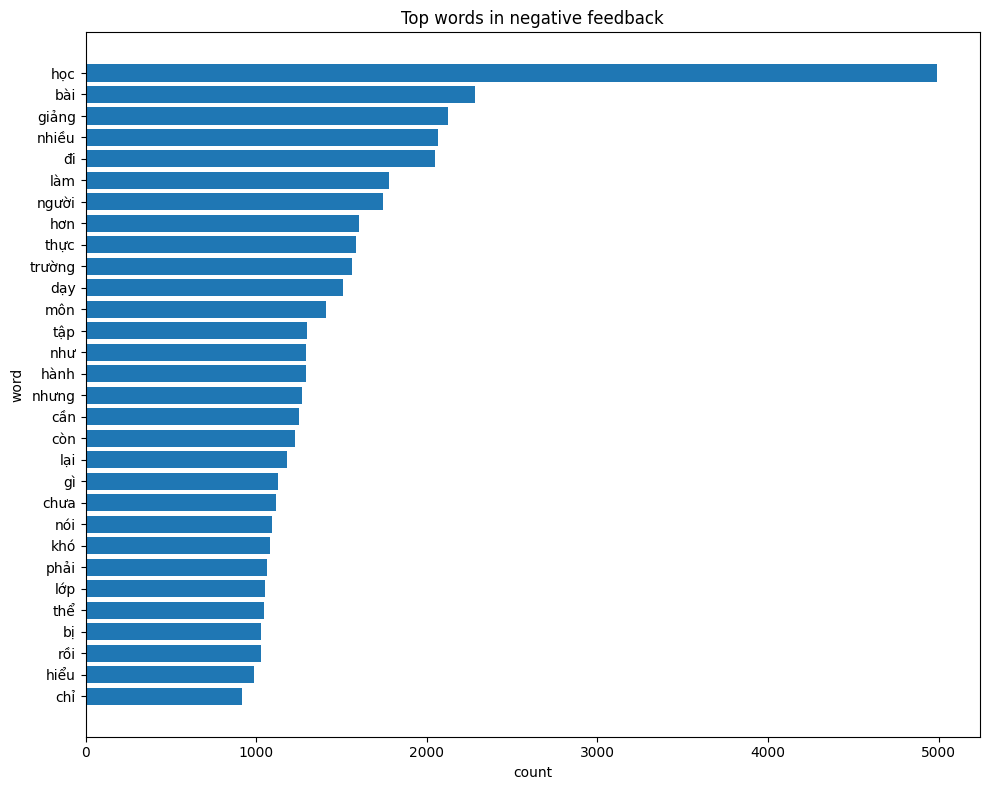

In [14]:
VI_STOPWORDS = {
    "và", "là", "của", "có", "cho", "một", "các", "những", "với", "trong",
    "được", "không", "này", "đó", "thì", "mà", "để", "em", "ạ", "rất",
    "quá", "nên", "cũng", "vì", "khi", "nếu", "ở", "về", "ra", "vào",
    "tôi", "mình", "bạn", "anh", "chị", "thầy", "cô", "sinh", "viên",
    "the", "and", "to", "of", "in", "for", "is", "are", "a", "an",
}

def tokenize_vi_simple(text):
    tokens = re.findall(r"\b\w+\b", str(text).lower(), flags=re.UNICODE)
    return [tok for tok in tokens if tok.isalpha() and len(tok) > 1 and tok not in VI_STOPWORDS]

negative_texts = eda_df.loc[eda_df["sentiment_std_3class"] == "negative", "text"]
counter = Counter()

for text in negative_texts:
    counter.update(tokenize_vi_simple(text))

top_negative_words = pd.DataFrame(counter.most_common(30), columns=["word", "count"])
display(top_negative_words)

if len(top_negative_words) > 0:
    plt.figure(figsize=(10, 8))
    plt.barh(top_negative_words["word"][::-1], top_negative_words["count"][::-1])
    plt.title("Top words in negative feedback")
    plt.xlabel("count")
    plt.ylabel("word")
    plt.tight_layout()
    negative_words_path = FIGURE_DIR / "negative_feedback_top_words.png"
    plt.savefig(negative_words_path, dpi=160)
    plt.show()
    figure_paths.append(negative_words_path)

## 14. Duplicate examples

Neu duplicate nam o nhieu split, can can nhac xu ly truoc khi train de tranh leakage.

In [15]:
duplicate_examples = (
    df[df.duplicated(subset=["text"], keep=False)]
    .sort_values(["text", "source_dataset", "split_original"])
    .head(30)
)

display(duplicate_examples)

,text,source_dataset,split_original,sentiment_raw,sentiment_std_code,sentiment_std_3class,sentiment_std_4class,topic_raw,topic_std,is_toxic,urgency_level
44259,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa th...",UIT_VSFC,train,2,1,positive,positive,0,lecturer,0,low
44383,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa th...",UIT_VSFC,train,0,2,negative,negative,0,lecturer,0,low


## 15. Nhan xet imbalance


In [16]:
def imbalance_table(df, column, min_pct=1.0):
    table = distribution_table(df[column]).reset_index()
    table.columns = [column, "count", "pct"]
    table["is_rare"] = table["pct"] < min_pct
    return table

imbalance_tables = {}
for col in ["sentiment_std_3class", "sentiment_std_4class", "topic_std"]:
    imbalance_tables[col] = imbalance_table(df, col)
    print("\n", col)
    display(imbalance_tables[col])


 sentiment_std_3class


,sentiment_std_3class,count,pct,is_rare
0,neutral,23471,47.76,False
1,negative,13484,27.44,False
2,positive,12186,24.80,False



 sentiment_std_4class


,sentiment_std_4class,count,pct,is_rare
0,neutral,23471,47.76,False
1,negative,12639,25.72,False
2,positive,12186,24.80,False
3,toxic,845,1.72,False



 topic_std


,topic_std,count,pct,is_rare
0,others,15218,30.97,False
1,lecturer,11607,23.62,False
2,academic,10512,21.39,False
3,training_program,3040,6.19,False
4,student_services,2358,4.80,False
5,personal_affairs,1478,3.01,False
6,news,902,1.84,False
7,jobs_recruitment,808,1.64,False
8,social_affairs,769,1.56,False
9,facilities,712,1.45,False


## 16. Ghi EDA report


In [17]:
def md_table_from_df(table):
    try:
        return table.to_markdown()
    except ImportError:
        return "```text\n" + table.to_string() + "\n```"

source_dist = distribution_table(df["source_dataset"])
split_dist = distribution_table(df["split_original"])
sentiment_3_dist = distribution_table(df["sentiment_std_3class"])
sentiment_4_dist = distribution_table(df["sentiment_std_4class"])
topic_dist = distribution_table(df["topic_std"])

report_lines = [
    "# EDA Report",
    "",
    "## Input",
    "",
    f"- CSV: `{MERGED_CSV.relative_to(PROJECT_ROOT)}`",
    f"- Rows: `{total_rows}`",
    f"- Columns: `{total_columns}`",
    "",
    "## Data quality",
    "",
    f"- Duplicate text rows: `{duplicate_text_count}`",
    f"- Duplicate text groups across splits: `{int(duplicate_cross_split)}`",
    "",
    "## Missing values",
    "",
    md_table_from_df(missing_table),
    "",
    "## Source distribution",
    "",
    md_table_from_df(source_dist),
    "",
    "## Split distribution",
    "",
    md_table_from_df(split_dist),
    "",
    "## Sentiment 3-class distribution",
    "",
    md_table_from_df(sentiment_3_dist),
    "",
    "## Sentiment 4-class distribution",
    "",
    md_table_from_df(sentiment_4_dist),
    "",
    "## Topic distribution",
    "",
    md_table_from_df(topic_dist),
    "",
    "## Text length summary",
    "",
    md_table_from_df(length_summary),
    "",
    "## Figures",
    "",
]

for path in figure_paths:
    report_lines.append(f"- `{path.relative_to(PROJECT_ROOT)}`")

report_lines.extend([
    "",
    "## Notes",
    "",
    "- Neu `sentiment_std_code` thieu, hay rerun Phase 1 de cap nhat schema moi nhat.",
    "- Duplicate hien chi duoc bao cao, chua drop tu dong.",
    "- Topic cua NEU va UIT khong hoan toan cung taxonomy, can can than khi train mot topic classifier chung.",
    "- Khi label lech manh, baseline nen bao cao macro-F1 va weighted-F1, khong chi accuracy.",
])

EDA_REPORT.write_text("\n".join(report_lines), encoding="utf-8")
print(f"Saved EDA report: {EDA_REPORT}")

Saved EDA report: d:\AI thuc chien\Student Voice Intelligence\outputs\reports\eda_report.md
